Which function? (0/1/2/3)
 0 : ZERO
 1 : ONE
 2 : SAME_AS
 3 : OPPOSITE_OF


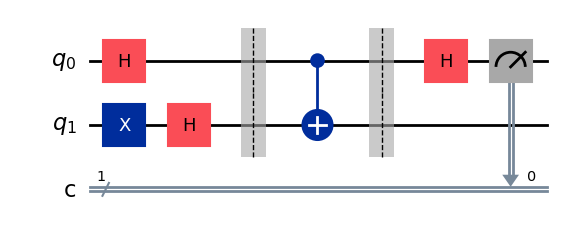

In [ ]:
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from enum import Enum

class SimpleBinary(Enum):
    Zero           = 0
    ONE            = 1
    SAME_AS        = 2
    OPPOSITE_OF    = 3

#تعریف توابع
def get_oracle(circ, function):
    # if function == SimpleBinary.Zero:
        # do nothing
    if function == SimpleBinary.ONE:
        circ.x(1)
    elif function == SimpleBinary.SAME_AS:
        circ.cx(0, 1)
    elif function == SimpleBinary.OPPOSITE_OF:
        circ.cx(0, 1)
        circ.x(1)
    return circ

#گرفتن ورودی از کاربر
def get_function():
    print('Which function? (0/1/2/3)')
    print(' 0 : ZERO')
    print(' 1 : ONE')
    print(' 2 : SAME_AS')
    print(' 3 : OPPOSITE_OF')
    
    value = input('> ')
    return SimpleBinary(int(value))

#ایجاد مدار
circ = QuantumCircuit(2, 1)
function = get_function()

circ.x(1)
circ.h(0)
circ.h(1)
circ.barrier()
circ = get_oracle(circ, function)
circ.barrier()
circ.h(0)
circ.measure(0, 0)

# برای نمایش مدار
display(circ.draw('mpl'))  

In [ ]:
#  اجرا روی شبیه‌ساز برای تشخیص نوع تابع
from qiskit_aer import AerSimulator

shots = 1024  #تعداد دفعات اجرا

simulator = AerSimulator()
job = simulator.run(circ, shots=1024)
result = job.result()
counts = result.get_counts(circ)

print(function)
print(counts)

number_of_0s = counts.get('0')
number_of_1s = counts.get('1')


if number_of_0s is not None and number_of_0s == shots:
    print('Constant')
elif number_of_1s is not None and number_of_1s == shots:
    print('Balanced')
else:
    print("Results aren't conclusive")

SimpleBinary.Zero
{'0': 1024}
Constant
